In [1]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

df = pd.read_csv(
    "/kaggle/input/datasets/lfreedom2750/predict-target-price-v2/next_day_price/arabica_selected_features_all_text.csv"
)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df = df.dropna().reset_index(drop=True)

X = df.drop(columns=["target_price", "date"])
y = df["target_price"]

train_end = "2025-02-28"
train_mask = df["date"] <= train_end

test_start = "2025-03-01"
test_mask = df["date"] >= test_start

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

In [2]:
print(y_test.mean())

204897.50990485435


In [3]:
tscv = TimeSeriesSplit(n_splits=5)

In [4]:
def directional_accuracy(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # actual movement
    actual_direction = np.sign(y_true[1:] - y_true[:-1])

    # predicted movement
    pred_direction = np.sign(y_pred[1:] - y_true[:-1])

    # accuracy
    da = np.mean(actual_direction == pred_direction)

    return da

In [5]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# HYPERPARAMETER GRID
# =========================
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

# =========================
# MODEL
# =========================
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
xgb_grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================
best_xgb = xgb_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, "best_xgboost.pkl")

joblib.dump(best_xgb, checkpoint_path)

print(f"Model saved to: {checkpoint_path}")

# =========================
# PREDICTION
# =========================
pred_xgb = best_xgb.predict(X_test)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_xgb)
mse = mean_squared_error(y_test, pred_xgb)
rmse = np.sqrt(mse)

da = directional_accuracy(y_test.values, pred_xgb)

print("Best Params:", xgb_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"DA   : {da:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model saved to: checkpoints/best_xgboost.pkl
Best Params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
MAE  : 10440.6209
MSE  : 177242698.1104
RMSE : 13313.2527
DA   : 0.5561


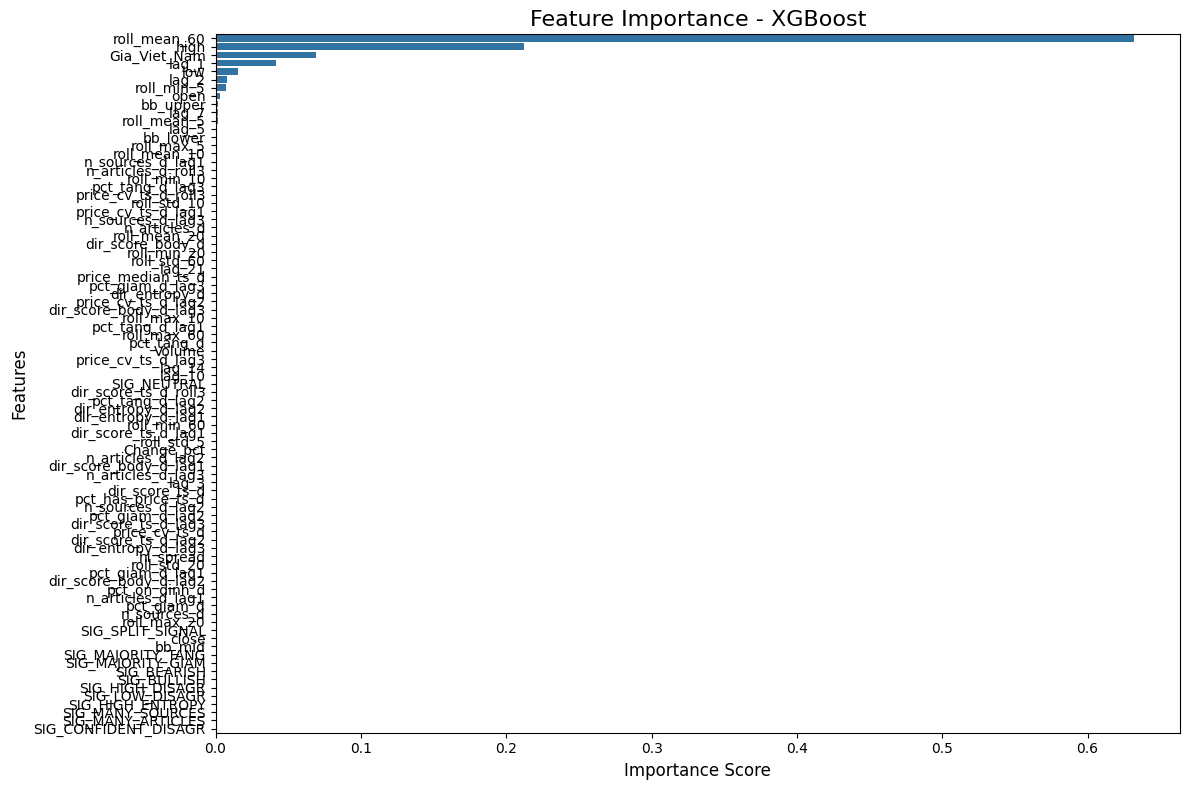

In [6]:
# =========================
# CELL — LIGHTGBM FEATURE IMPORTANCE
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# CREATE IMPORTANCE DATAFRAME
# =========================
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

# =========================
# SORT FEATURES
# =========================
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# =========================
# PLOT ALL FEATURES
# =========================
plt.figure(figsize=(12, 8))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance - XGBoost",
    fontsize=16
)

plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_price_from_volatility(
    df,
    test_mask,
    y_test,
    y_pred,
    model_name,
    price_col="Gia_Viet_Nam",
    date_col="date"
):
    # =========================
    # TEST DATA
    # =========================
    test_dates = df.loc[
        test_mask,
        date_col
    ].reset_index(drop=True)

    current_price = df.loc[
        test_mask,
        price_col
    ].reset_index(drop=True)

    y_test = y_test.reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    # =========================
    # CONVERT VOLATILITY -> PRICE
    # =========================
    actual_price = current_price + y_test
    predicted_price = current_price + y_pred

    # =========================
    # PLOT
    # =========================
    plt.figure(figsize=(18, 6))

    plt.plot(
        test_dates,
        actual_price,
        label="Actual Price",
        linewidth=2
    )

    plt.plot(
        test_dates,
        predicted_price,
        label="Predicted Price",
        linewidth=2
    )

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    plt.title(
        f"{model_name} - Actual vs Predicted Coffee Price",
        fontsize=16
    )

    plt.xlabel("Date")
    plt.ylabel("Coffee Price")

    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

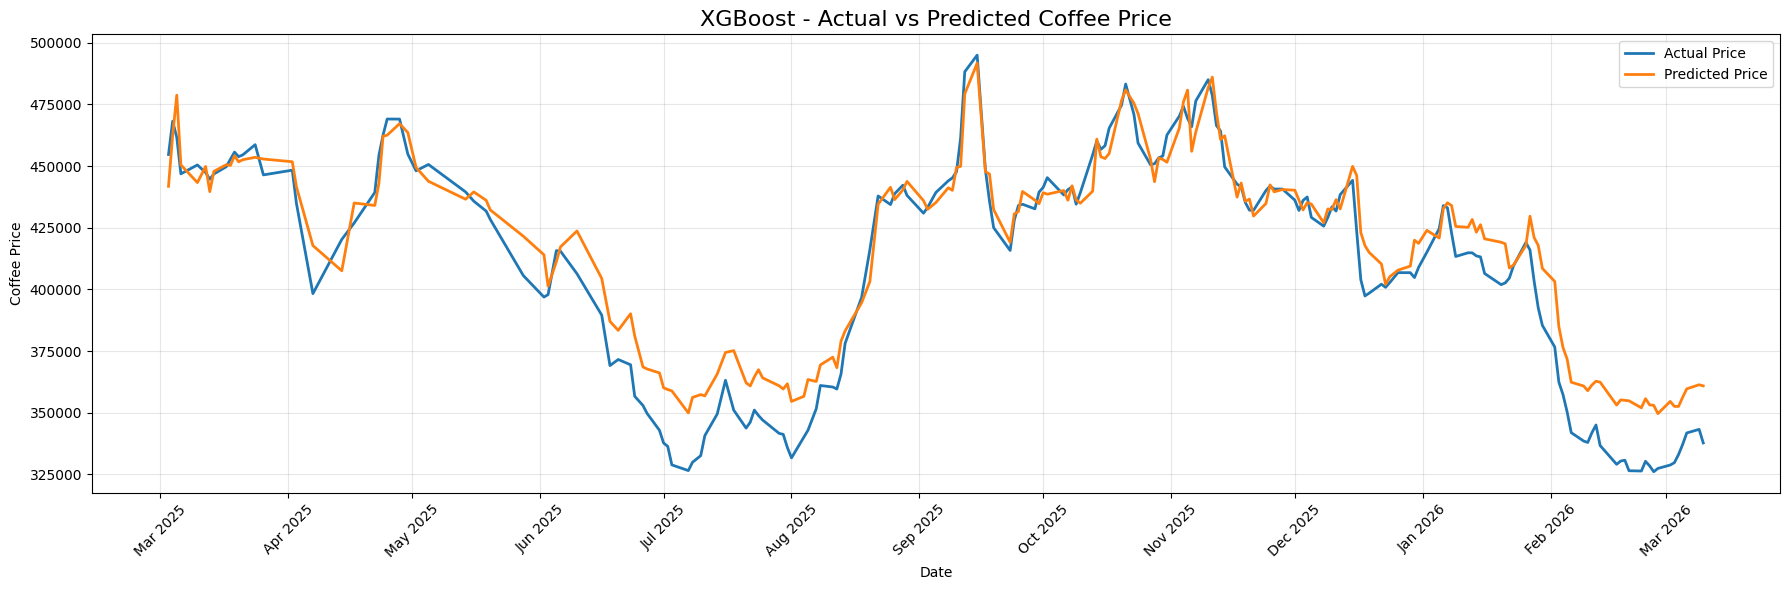

In [8]:
plot_price_from_volatility(df, test_mask, y_test, pred_xgb, "XGBoost")

In [9]:
# =========================
# CELL 3 — LIGHTGBM
# =========================

from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

# =========================
# HYPERPARAMETER GRID
# =========================
lgbm_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, -1],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50]
}

# =========================
# MODEL
# =========================
lgbm_model = LGBMRegressor(
    random_state=42,
    verbose=-1
)

# =========================
# GRID SEARCH
# =========================
lgbm_grid = GridSearchCV(
    estimator=lgbm_model,
    param_grid=lgbm_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0
)

# =========================
# TRAINING
# =========================
lgbm_grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================
best_lgbm = lgbm_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(
    checkpoint_dir,
    "best_lightgbm.pkl"
)

joblib.dump(best_lgbm, checkpoint_path)

print(f"Model saved to: {checkpoint_path}")

# =========================
# PREDICTION
# =========================
pred_lgbm = best_lgbm.predict(X_test)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_lgbm)
mse = mean_squared_error(y_test, pred_lgbm)
rmse = np.sqrt(mse)

da = directional_accuracy(y_test.values, pred_lgbm)

print("Best Params:", lgbm_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"DA   : {da:.4f}")

Model saved to: checkpoints/best_lightgbm.pkl
Best Params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31}
MAE  : 14520.4866
MSE  : 318259003.4963
RMSE : 17839.8151
DA   : 0.5317


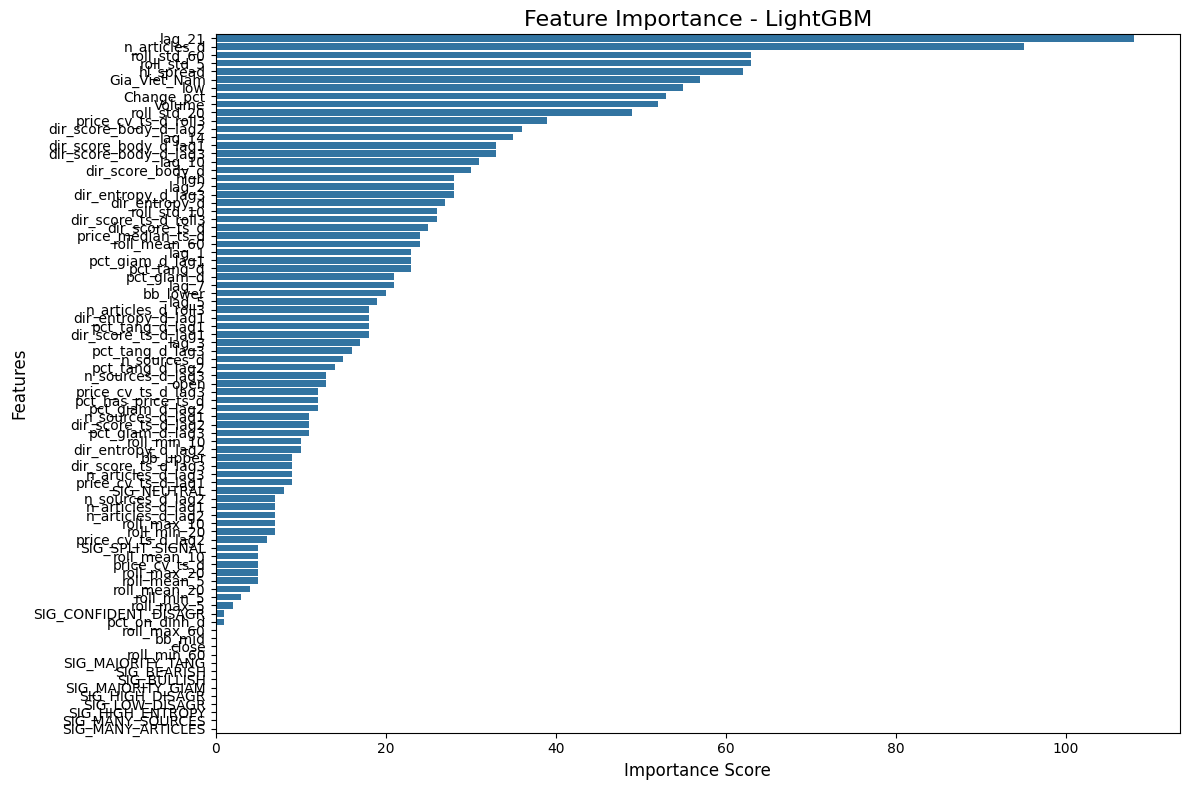

In [10]:
# =========================
# CELL — LIGHTGBM FEATURE IMPORTANCE
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# CREATE IMPORTANCE DATAFRAME
# =========================
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_lgbm.feature_importances_
})

# =========================
# SORT FEATURES
# =========================
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# =========================
# PLOT ALL FEATURES
# =========================
plt.figure(figsize=(12, 8))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance - LightGBM",
    fontsize=16
)

plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

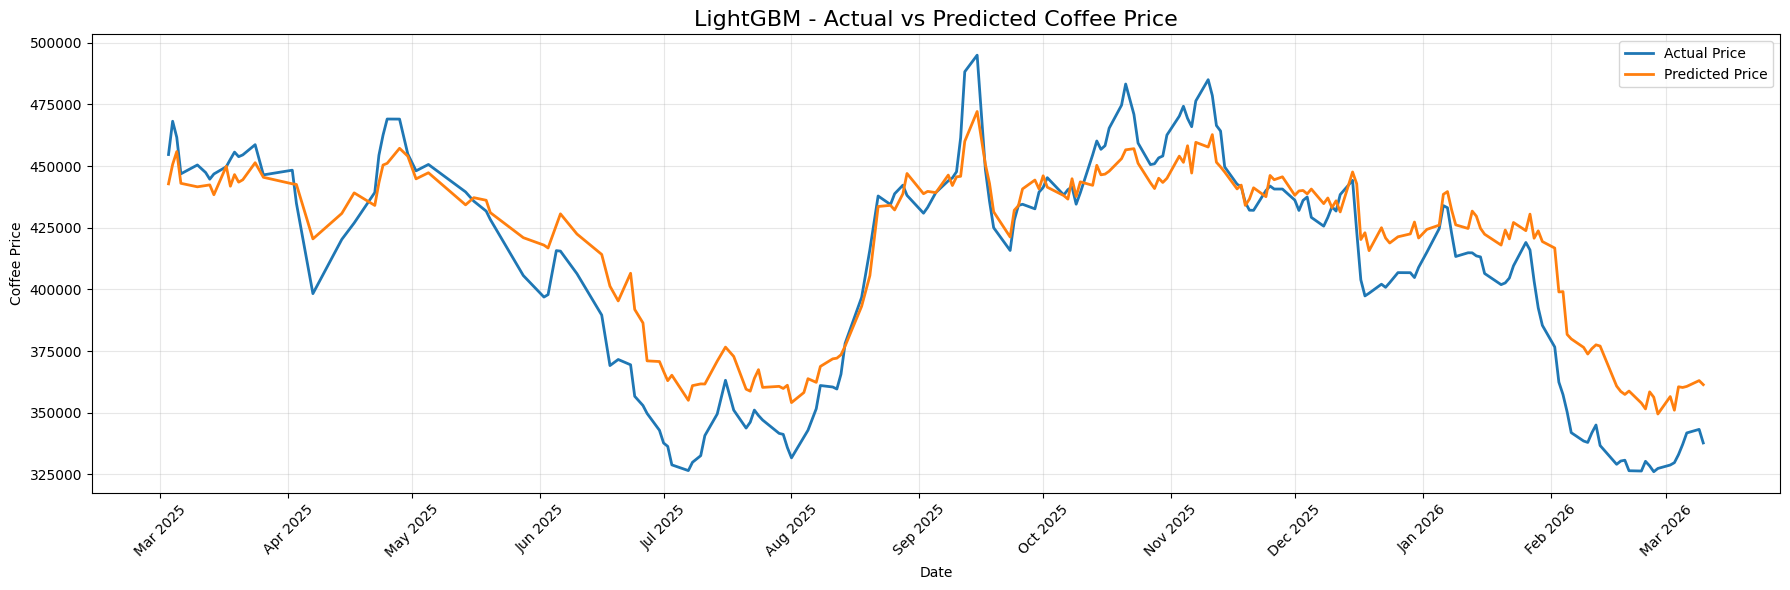

In [11]:
plot_price_from_volatility(df, test_mask, y_test, pred_lgbm, "LightGBM")

In [12]:
# =========================
# CELL 5 — LASSO
# =========================

from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib
import os

# =========================
# SCALE DATA
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# HYPERPARAMETER GRID
# =========================
lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]
}

# =========================
# MODEL
# =========================
lasso_model = Lasso(
    max_iter=10000,
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
lasso_grid = GridSearchCV(
    estimator=lasso_model,
    param_grid=lasso_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
lasso_grid.fit(X_train_scaled, y_train)

# =========================
# BEST MODEL
# =========================
best_lasso = lasso_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save model
model_path = os.path.join(checkpoint_dir, "best_lasso.pkl")
joblib.dump(best_lasso, model_path)

# Save scaler
scaler_path = os.path.join(checkpoint_dir, "lasso_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

# =========================
# PREDICTION
# =========================
pred_lasso = best_lasso.predict(X_test_scaled)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_lasso)
mse = mean_squared_error(y_test, pred_lasso)
rmse = np.sqrt(mse)

da = directional_accuracy(y_test.values, pred_lasso)

print("Best Params:", lasso_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"DA   : {da:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.428e+07, tolerance: 3.558e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.099e+06, tolerance: 1.065e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.886e+08, tolerance: 1.353e

Model saved to: checkpoints/best_lasso.pkl
Scaler saved to: checkpoints/lasso_scaler.pkl
Best Params: {'alpha': 1.0}
MAE  : 5002.0946
MSE  : 39249928.9006
RMSE : 6264.9764
DA   : 0.5220


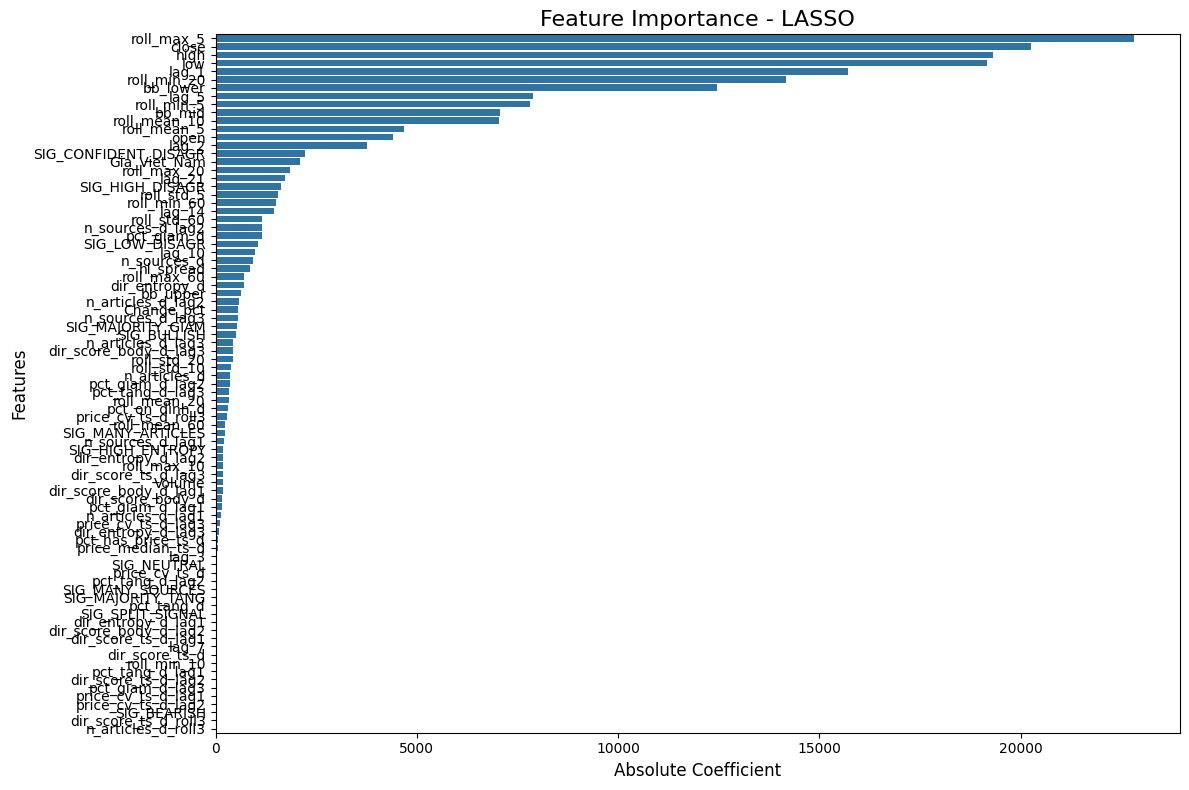

In [13]:
# =========================
# CELL — LASSO FEATURE IMPORTANCE
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# CREATE COEFFICIENT DATAFRAME
# =========================
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_lasso.coef_
})

# =========================
# ABSOLUTE IMPORTANCE
# =========================
coef_df["Abs_Coefficient"] = np.abs(
    coef_df["Coefficient"]
)

# =========================
# SORT FEATURES
# =========================
coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

# =========================
# PLOT ALL FEATURES
# =========================
plt.figure(figsize=(12, 8))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title(
    "Feature Importance - LASSO",
    fontsize=16
)

plt.xlabel("Absolute Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

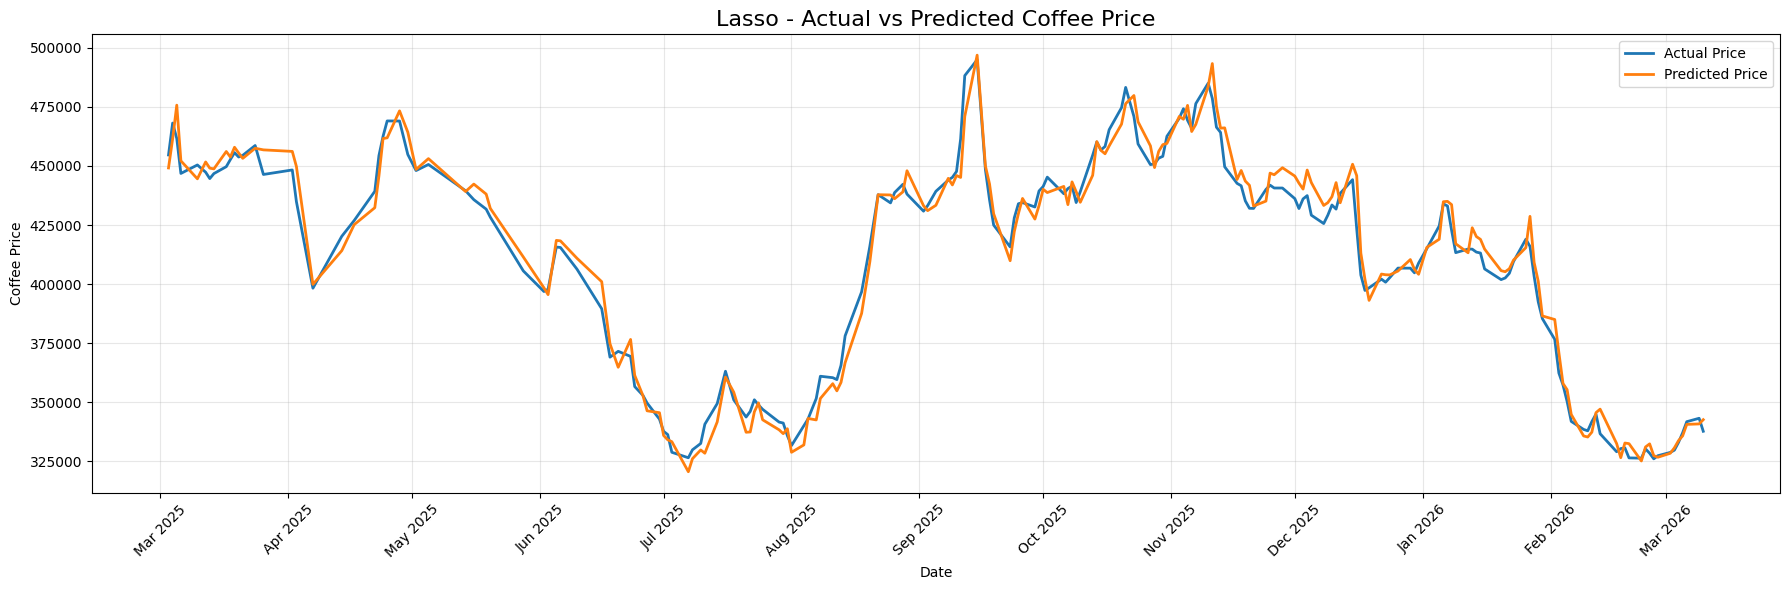

In [14]:
plot_price_from_volatility(df, test_mask, y_test, pred_lasso, "Lasso")

In [15]:
# =========================
# CELL — RIDGE REGRESSION
# =========================

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# HYPERPARAMETER GRID
# =========================
ridge_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
}

# =========================
# MODEL
# =========================
ridge_model = Ridge(
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
ridge_grid = GridSearchCV(
    estimator=ridge_model,
    param_grid=ridge_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
ridge_grid.fit(X_train_scaled, y_train)

# =========================
# BEST MODEL
# =========================
best_ridge = ridge_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save model
model_path = os.path.join(checkpoint_dir, "best_ridge.pkl")
joblib.dump(best_ridge, model_path)

# Save scaler
scaler_path = os.path.join(checkpoint_dir, "ridge_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

# =========================
# PREDICTION
# =========================
pred_ridge = best_ridge.predict(X_test_scaled)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_ridge)
mse = mean_squared_error(y_test, pred_ridge)
rmse = np.sqrt(mse)

da = directional_accuracy(y_test.values, pred_ridge)

print("Best Params:", ridge_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"DA   : {da:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Model saved to: checkpoints/best_ridge.pkl
Scaler saved to: checkpoints/ridge_scaler.pkl
Best Params: {'alpha': 1.0}
MAE  : 4890.8851
MSE  : 38532248.9577
RMSE : 6207.4350
DA   : 0.5659


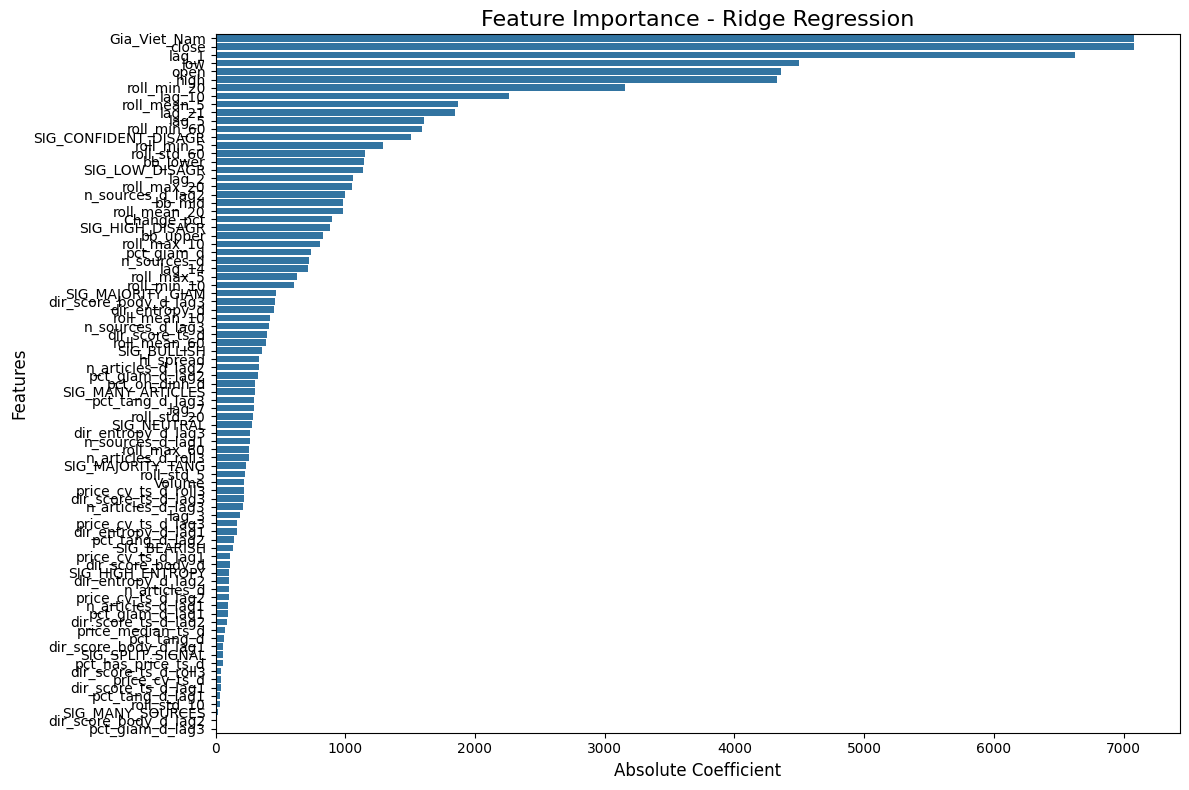

In [16]:
# =========================
# CELL — RIDGE FEATURE IMPORTANCE
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# CREATE COEFFICIENT DATAFRAME
# =========================
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_ridge.coef_
})

# =========================
# ABSOLUTE IMPORTANCE
# =========================
coef_df["Abs_Coefficient"] = np.abs(
    coef_df["Coefficient"]
)

# =========================
# SORT FEATURES
# =========================
coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

# =========================
# PLOT ALL FEATURES
# =========================
plt.figure(figsize=(12, 8))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title(
    "Feature Importance - Ridge Regression",
    fontsize=16
)

plt.xlabel("Absolute Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

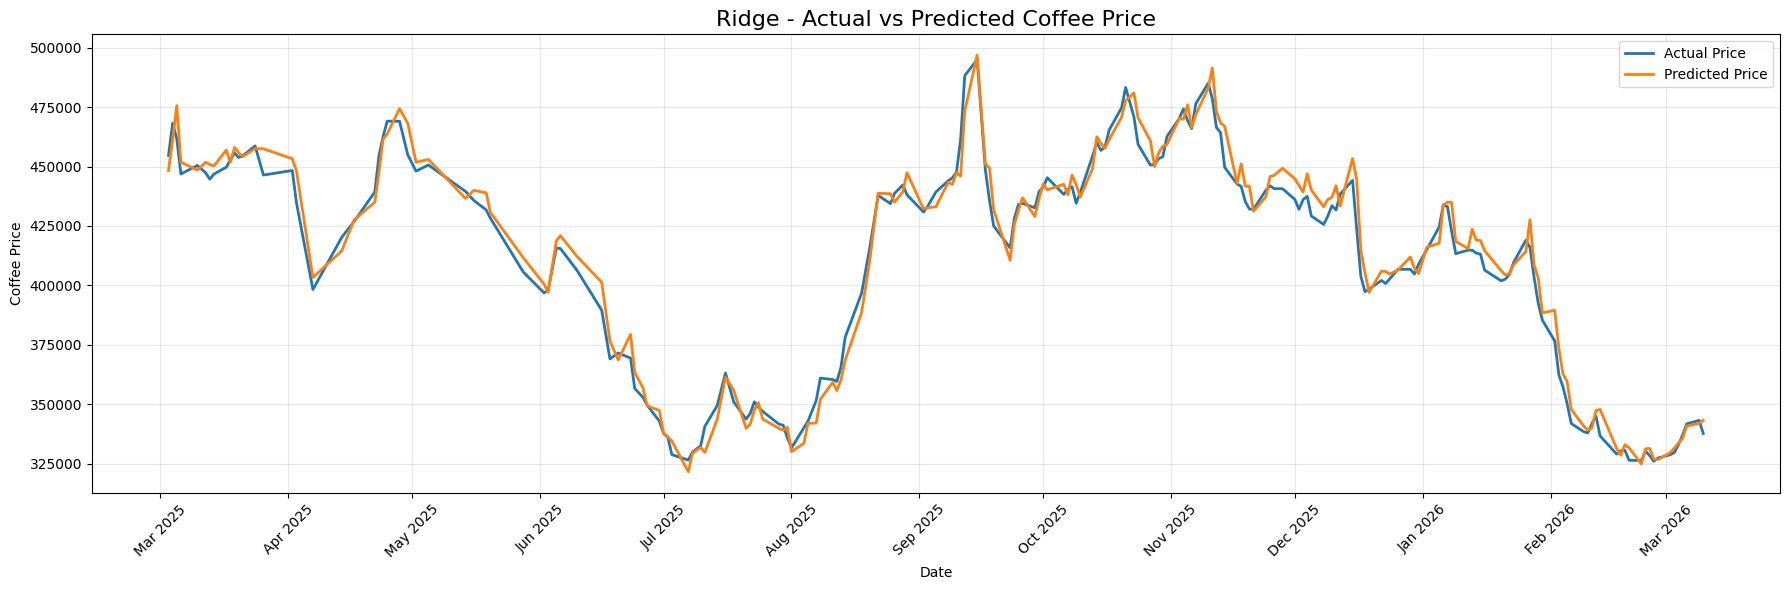

In [17]:
plot_price_from_volatility(df, test_mask, y_test, pred_ridge, "Ridge")

In [18]:
# =========================
# CELL — ELASTIC NET
# =========================

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# HYPERPARAMETER GRID
# =========================
elastic_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "l1_ratio": [0.2, 0.5, 0.8]
}

# =========================
# MODEL
# =========================
elastic_model = ElasticNet(
    max_iter=10000,
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
elastic_grid = GridSearchCV(
    estimator=elastic_model,
    param_grid=elastic_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
elastic_grid.fit(X_train_scaled, y_train)

# =========================
# BEST MODEL
# =========================
best_elastic = elastic_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save model
model_path = os.path.join(checkpoint_dir, "best_elasticnet.pkl")
joblib.dump(best_elastic, model_path)

# Save scaler
scaler_path = os.path.join(checkpoint_dir, "elasticnet_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

# =========================
# PREDICTION
# =========================
pred_elastic = best_elastic.predict(X_test_scaled)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_elastic)
mse = mean_squared_error(y_test, pred_elastic)
rmse = np.sqrt(mse)

da = directional_accuracy(y_test.values, pred_elastic)

print("Best Params:", elastic_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"DA   : {da:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.877e+07, tolerance: 3.558e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.701e+07, tolerance: 1.065e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.269e+08, tolerance: 6.148e

Model saved to: checkpoints/best_elasticnet.pkl
Scaler saved to: checkpoints/elasticnet_scaler.pkl
Best Params: {'alpha': 0.01, 'l1_ratio': 0.2}
MAE  : 4987.0273
MSE  : 40539699.3436
RMSE : 6367.0793
DA   : 0.5756


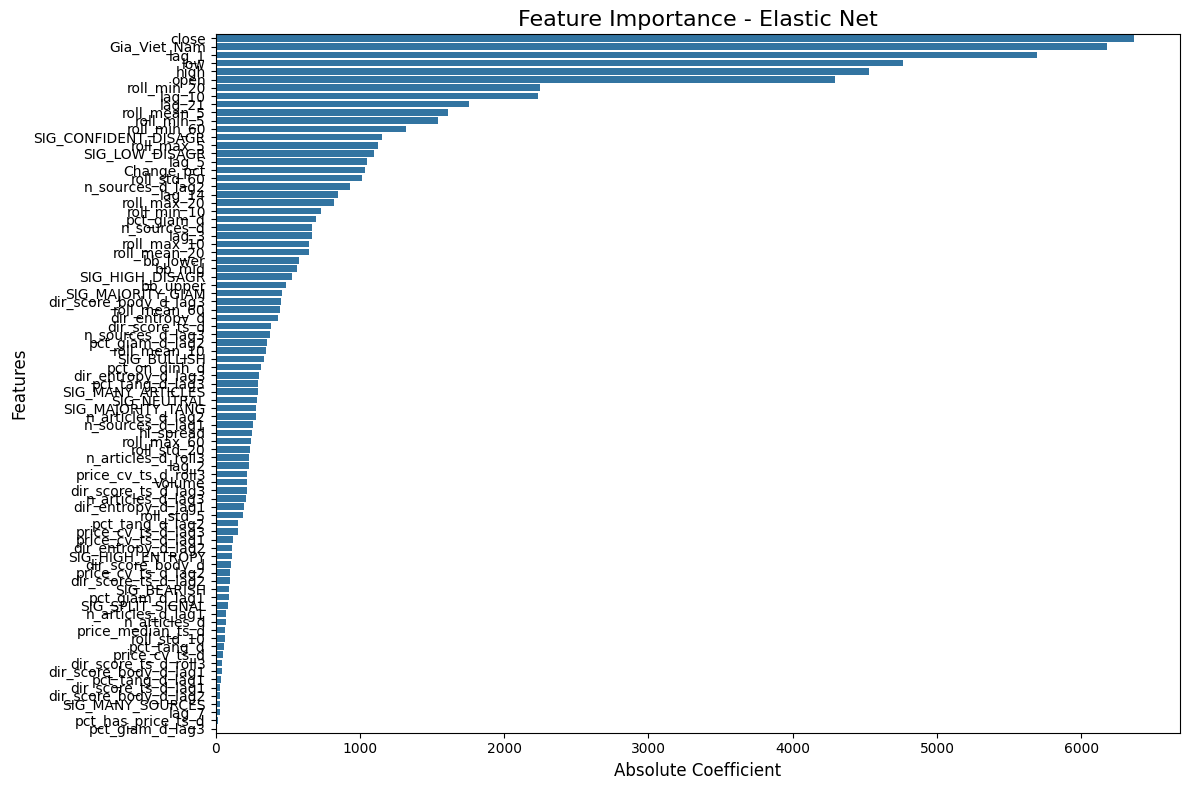

In [19]:
# =========================
# CELL — ELASTIC NET FEATURE IMPORTANCE
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# CREATE COEFFICIENT DATAFRAME
# =========================
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_elastic.coef_
})

# =========================
# ABSOLUTE IMPORTANCE
# =========================
coef_df["Abs_Coefficient"] = np.abs(
    coef_df["Coefficient"]
)

# =========================
# SORT FEATURES
# =========================
coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

# =========================
# PLOT ALL FEATURES
# =========================
plt.figure(figsize=(12, 8))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title(
    "Feature Importance - Elastic Net",
    fontsize=16
)

plt.xlabel("Absolute Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

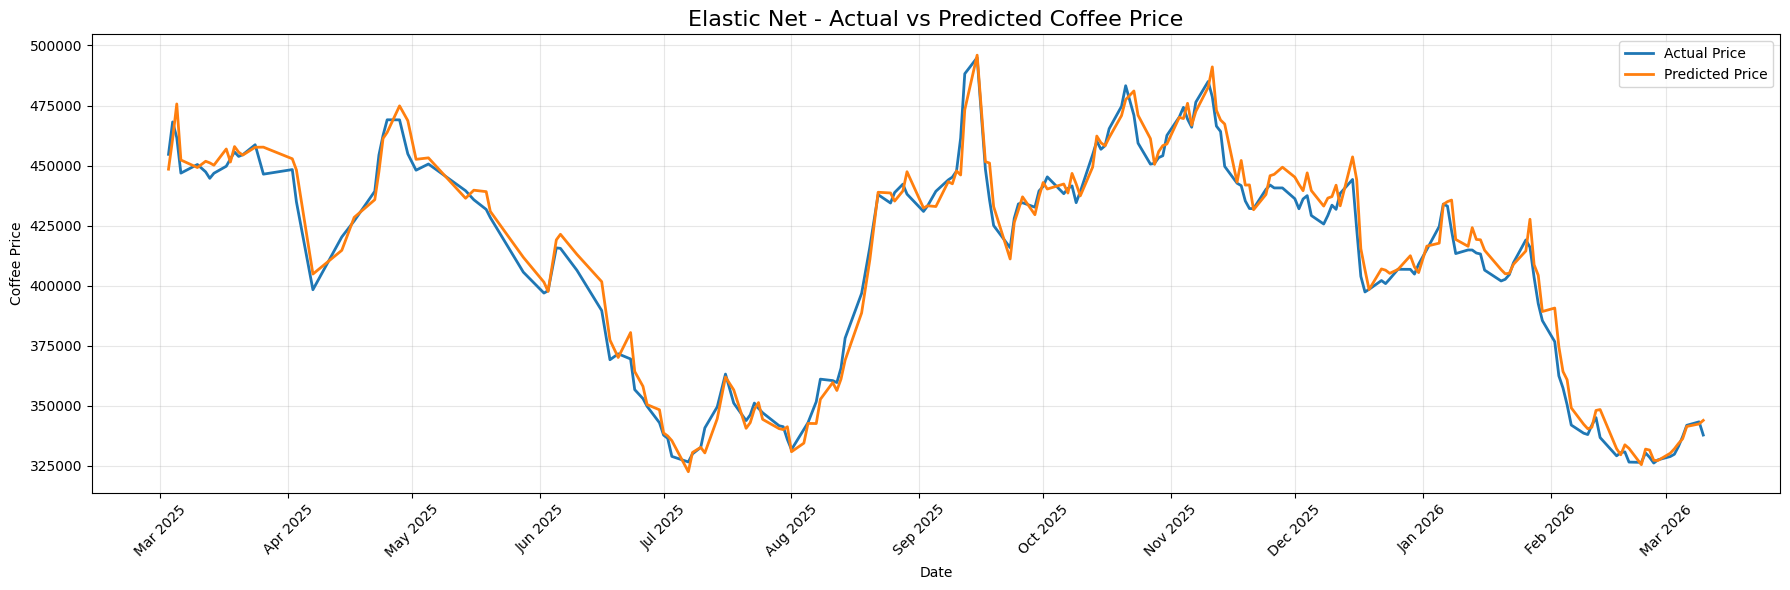

In [20]:
plot_price_from_volatility(df, test_mask, y_test, pred_elastic, "Elastic Net")

In [21]:
# =========================
# CELL — SVM REGRESSION
# =========================

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib
import os

# =========================
# SCALE DATA
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# HYPERPARAMETER GRID
# =========================
svr_params = [
    # Linear SVM
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10, 100],
        "epsilon": [0.001, 0.01, 0.1]
    },

    # Kernel SVM (RBF)
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10, 100],
        "epsilon": [0.001, 0.01, 0.1],
        "gamma": ["scale", "auto"]
    }
]

# =========================
# MODEL
# =========================
svr_model = SVR()

# =========================
# GRID SEARCH
# =========================
svr_grid = GridSearchCV(
    estimator=svr_model,
    param_grid=svr_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
svr_grid.fit(X_train_scaled, y_train)

# =========================
# BEST MODEL
# =========================
best_svr = svr_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save model
model_path = os.path.join(checkpoint_dir, "best_svr.pkl")
joblib.dump(best_svr, model_path)

# Save scaler
scaler_path = os.path.join(checkpoint_dir, "svr_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

# =========================
# PREDICTION
# =========================
pred_svr = best_svr.predict(X_test_scaled)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_svr)
mse = mean_squared_error(y_test, pred_svr)
rmse = np.sqrt(mse)

da = directional_accuracy(y_test.values, pred_svr)

print("Best Params:", svr_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"DA   : {da:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model saved to: checkpoints/best_svr.pkl
Scaler saved to: checkpoints/svr_scaler.pkl
Best Params: {'C': 100, 'epsilon': 0.1, 'kernel': 'linear'}
MAE  : 10289.8655
MSE  : 152068638.4818
RMSE : 12331.6113
DA   : 0.5073


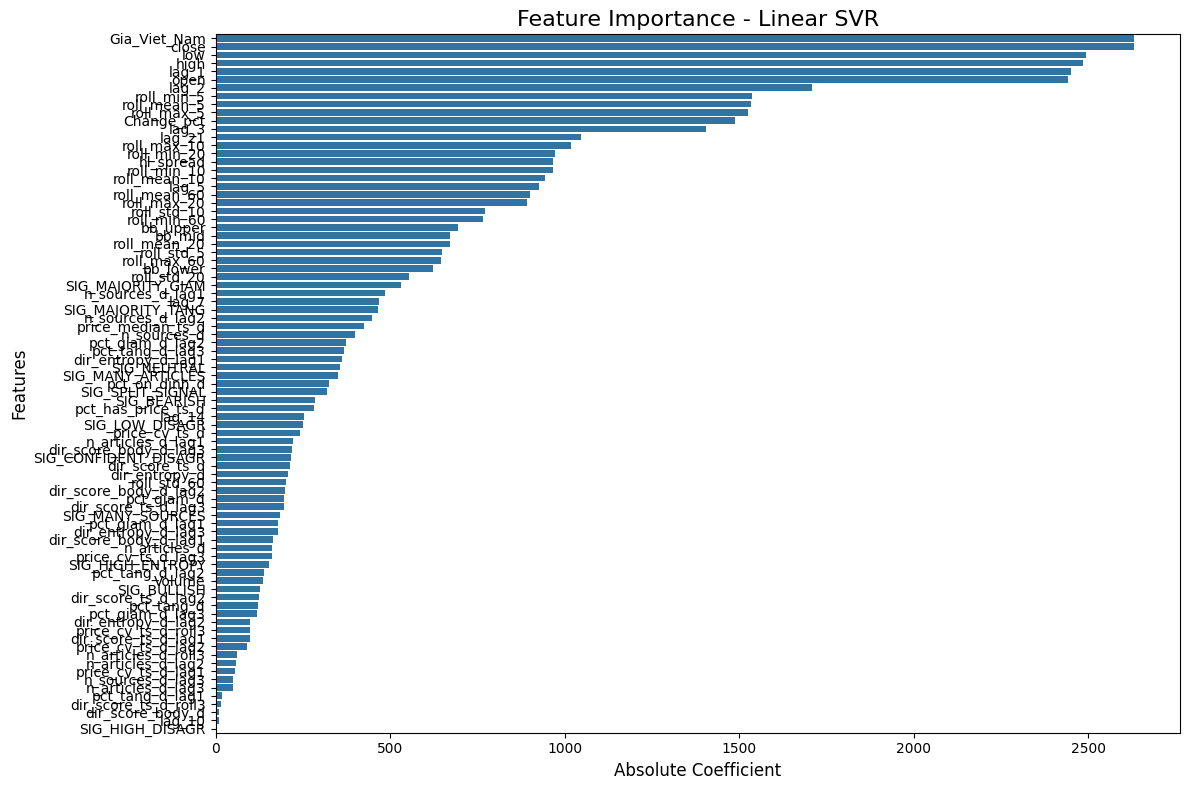

In [22]:
# =========================
# CELL — SVM FEATURE IMPORTANCE
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# CHECK KERNEL TYPE
# =========================
if best_svr.kernel == "linear":

    # =========================
    # CREATE COEFFICIENT DATAFRAME
    # =========================
    coef_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": best_svr.coef_[0]
    })

    # =========================
    # ABSOLUTE IMPORTANCE
    # =========================
    coef_df["Abs_Coefficient"] = np.abs(
        coef_df["Coefficient"]
    )

    # =========================
    # SORT FEATURES
    # =========================
    coef_df = coef_df.sort_values(
        by="Abs_Coefficient",
        ascending=False
    )

    # =========================
    # PLOT ALL FEATURES
    # =========================
    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=coef_df,
        x="Abs_Coefficient",
        y="Feature"
    )

    plt.title(
        "Feature Importance - Linear SVR",
        fontsize=16
    )

    plt.xlabel("Absolute Coefficient", fontsize=12)
    plt.ylabel("Features", fontsize=12)

    plt.tight_layout()
    plt.show()

else:

    print("Feature importance trực tiếp không khả dụng cho RBF SVR.")
    print("Hãy dùng permutation importance.")

    # =========================
    # PERMUTATION IMPORTANCE
    # =========================
    from sklearn.inspection import permutation_importance

    result = permutation_importance(
        best_svr,
        X_test_scaled,
        y_test,
        n_repeats=10,
        random_state=42,
        scoring="neg_mean_absolute_error"
    )

    # =========================
    # CREATE IMPORTANCE DATAFRAME
    # =========================
    importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": result.importances_mean
    })

    # =========================
    # SORT FEATURES
    # =========================
    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    # =========================
    # PLOT ALL FEATURES
    # =========================
    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature"
    )

    plt.title(
        "Permutation Feature Importance - RBF SVR",
        fontsize=16
    )

    plt.xlabel("Importance", fontsize=12)
    plt.ylabel("Features", fontsize=12)

    plt.tight_layout()
    plt.show()

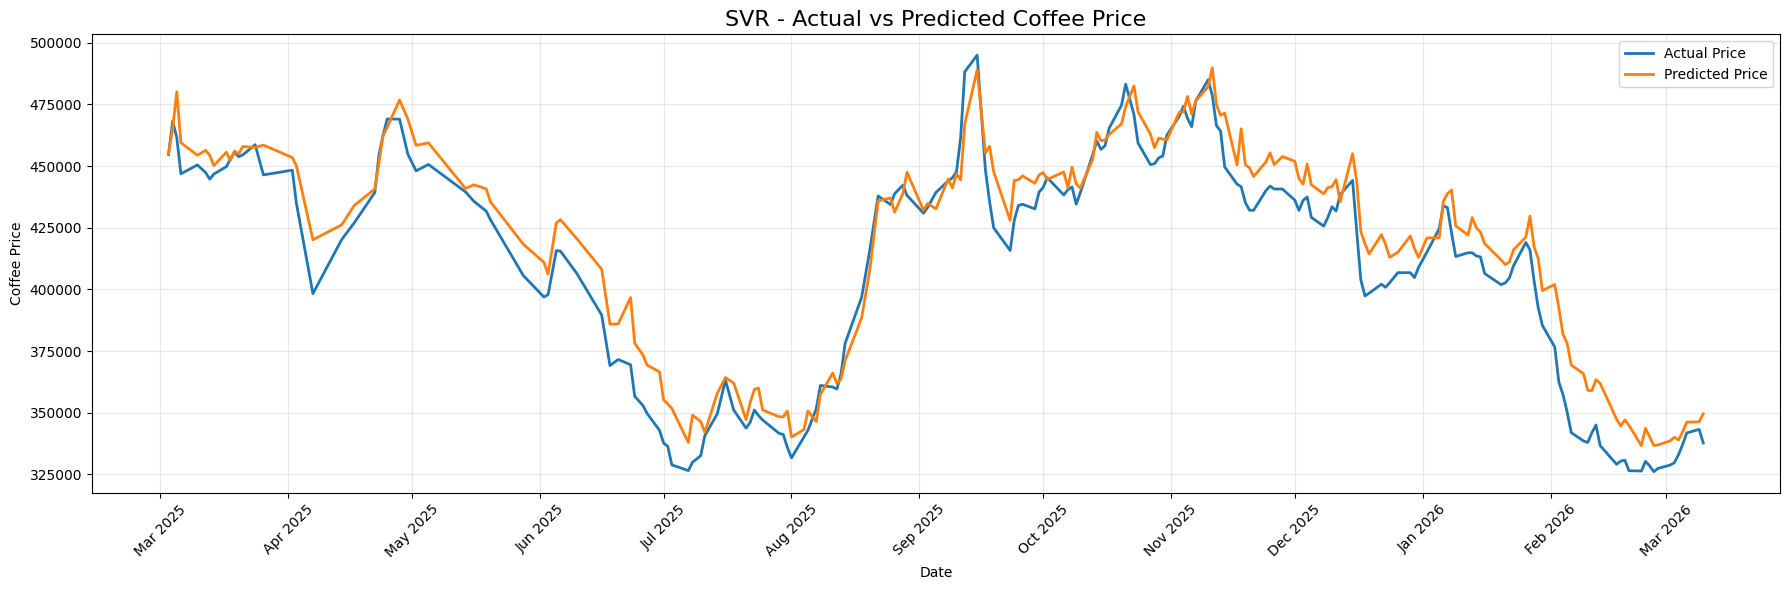

In [23]:
plot_price_from_volatility(df, test_mask, y_test, pred_svr, "SVR")

In [24]:
# =========================
# CELL — SAVE ALL MODEL METRICS
# =========================

import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================
# DIRECTIONAL ACCURACY
# =========================

def directional_accuracy(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # actual direction
    actual_direction = np.sign(
        y_true[1:] - y_true[:-1]
    )

    # predicted direction
    pred_direction = np.sign(
        y_pred[1:] - y_true[:-1]
    )

    # directional accuracy
    da = np.mean(
        actual_direction == pred_direction
    )

    return da

# =========================
# CREATE METRICS TABLE
# =========================

metrics_df = pd.DataFrame({

    "Model": [
        "XGBoost",
        "LightGBM",
        "LASSO",
        "Ridge",
        "ElasticNet",
        "SVR"
    ],

    "MAE": [
        mean_absolute_error(y_test, pred_xgb),
        mean_absolute_error(y_test, pred_lgbm),
        mean_absolute_error(y_test, pred_lasso),
        mean_absolute_error(y_test, pred_ridge),
        mean_absolute_error(y_test, pred_elastic),
        mean_absolute_error(y_test, pred_svr)
    ],

    "MSE": [
        mean_squared_error(y_test, pred_xgb),
        mean_squared_error(y_test, pred_lgbm),
        mean_squared_error(y_test, pred_lasso),
        mean_squared_error(y_test, pred_ridge),
        mean_squared_error(y_test, pred_elastic),
        mean_squared_error(y_test, pred_svr)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_xgb)),
        np.sqrt(mean_squared_error(y_test, pred_lgbm)),
        np.sqrt(mean_squared_error(y_test, pred_lasso)),
        np.sqrt(mean_squared_error(y_test, pred_ridge)),
        np.sqrt(mean_squared_error(y_test, pred_elastic)),
        np.sqrt(mean_squared_error(y_test, pred_svr))
    ],

    "R2 Score": [
        r2_score(y_test, pred_xgb),
        r2_score(y_test, pred_lgbm),
        r2_score(y_test, pred_lasso),
        r2_score(y_test, pred_ridge),
        r2_score(y_test, pred_elastic),
        r2_score(y_test, pred_svr)
    ],

    "Directional Accuracy": [
        directional_accuracy(y_test.values, pred_xgb),
        directional_accuracy(y_test.values, pred_lgbm),
        directional_accuracy(y_test.values, pred_lasso),
        directional_accuracy(y_test.values, pred_ridge),
        directional_accuracy(y_test.values, pred_elastic),
        directional_accuracy(y_test.values, pred_svr)
    ]
})

# =========================
# SORT BY RMSE
# =========================

metrics_df = metrics_df.sort_values(
    by="RMSE",
    ascending=True
)

# =========================
# SAVE CSV
# =========================

metrics_df.to_csv(
    "all_model_metrics.csv",
    index=False
)

# =========================
# DISPLAY
# =========================

print(metrics_df)

print("\nSaved: all_model_metrics.csv")

        Model           MAE           MSE          RMSE  R2 Score  \
3       Ridge   4890.885070  3.853225e+07   6207.434974  0.931718   
2       LASSO   5002.094607  3.924993e+07   6264.976369  0.930446   
4  ElasticNet   4987.027277  4.053970e+07   6367.079342  0.928161   
5         SVR  10289.865454  1.520686e+08  12331.611350  0.730524   
0     XGBoost  10440.620940  1.772427e+08  13313.252725  0.685913   
1    LightGBM  14520.486625  3.182590e+08  17839.815119  0.436022   

   Directional Accuracy  
3              0.565854  
2              0.521951  
4              0.575610  
5              0.507317  
0              0.556098  
1              0.531707  

Saved: all_model_metrics.csv


In [25]:
import shutil

folder_path = "/kaggle/working/checkpoints"

output_zip = "checkpoints_backup"

# tạo file zip
shutil.make_archive(
    output_zip,   # tên file zip
    'zip',        # định dạng
    folder_path   # folder nguồn
)

print("Done!")

Done!
